Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/confmat_L1_B100.pdf


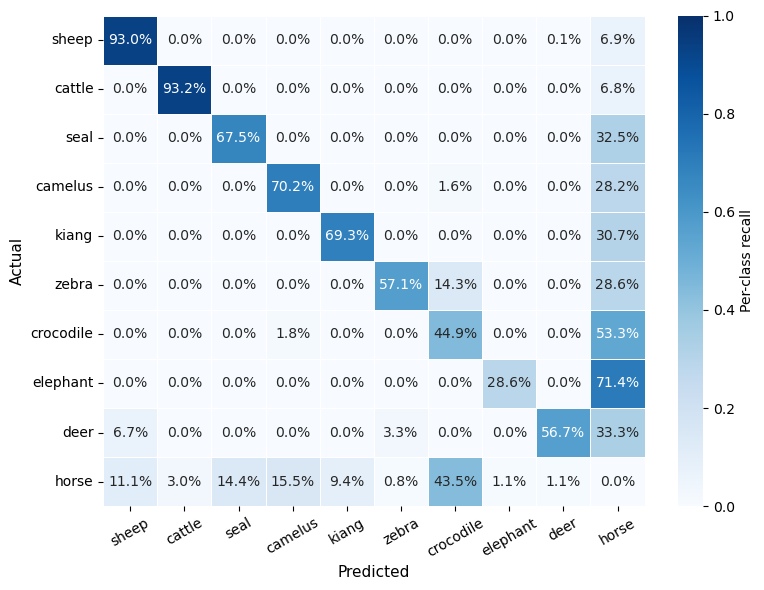

Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/confmat_L2_B100.pdf


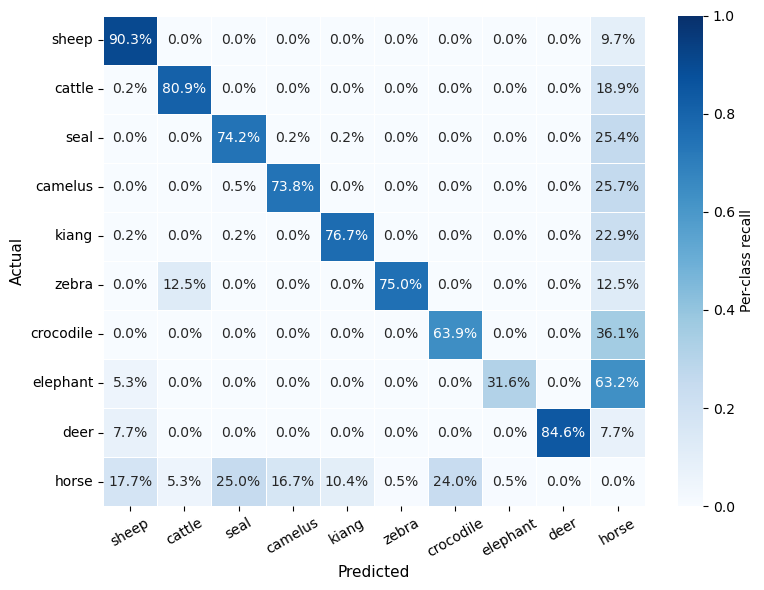

Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/confmat_L3_B100.pdf


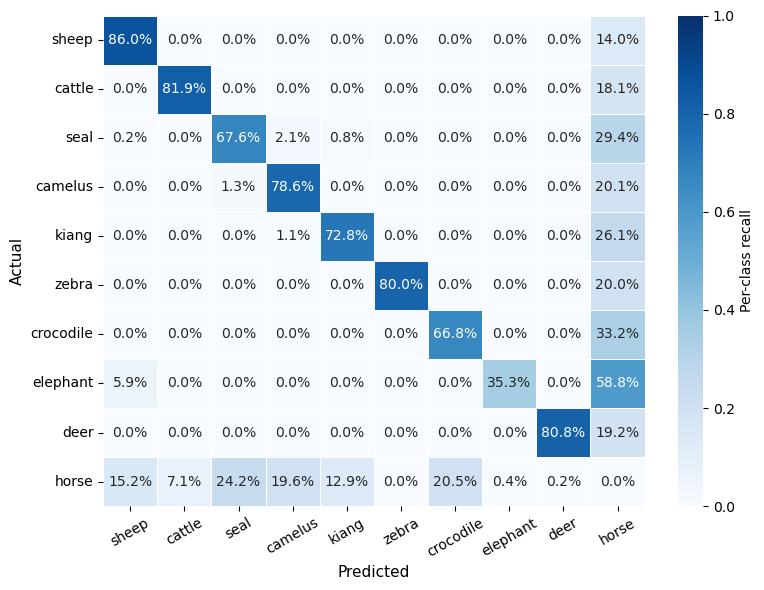

Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/confmat_L4_B100.pdf


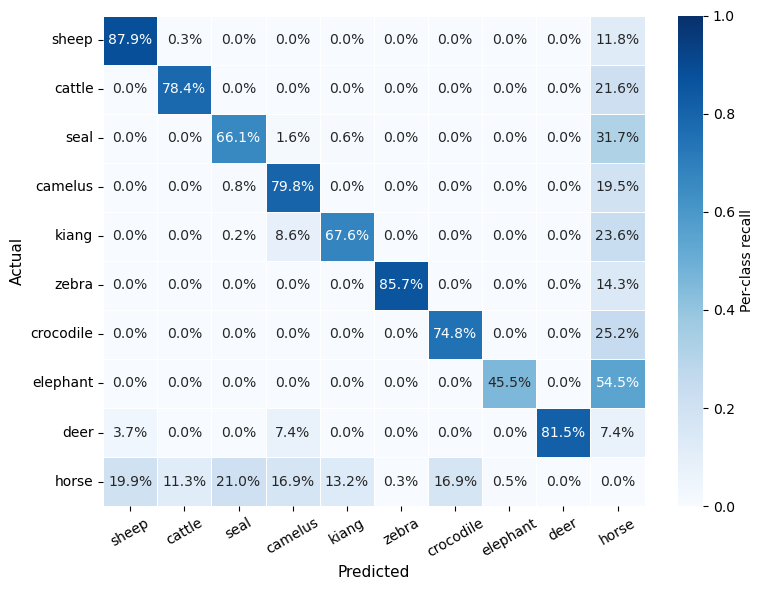

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import yaml   # PyYAML

# Directorios
FILE_DIR = os.path.abspath("")          # normalmente /home/fozamorano/WAID/src
ROOT_DIR = os.path.join(FILE_DIR, "..") # → /home/fozamorano/WAID
LOG_DIR  = os.path.join(ROOT_DIR, "logs", "ValWAID+")
OUT_DIR  = os.path.join(ROOT_DIR, "plots/ConfMat_WAID+/")
os.makedirs(OUT_DIR, exist_ok=True)

# Leer nombres de clase desde waidplus.yaml en la raíz de WAID
DATA_YAML = os.path.join(FILE_DIR, "waidplus.yaml")
with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

# names:
#   0: sheep
#   1: cattle
CLASS_NAMES = {int(k): v for k, v in data_cfg["names"].items()}


def DibujarMatrizConf(levels=["L1", "L2", "L3", "L4"], batch="B100"):
    lvl_list = levels if isinstance(levels, list) else [levels]

    for lvl in lvl_list:
        path = os.path.join(LOG_DIR, f"confmat_{lvl}_{batch}.csv")
        if not os.path.exists(path):
            print(f"[WARNING] Not found: {path}")
            continue

        # Leer CSV tal cual
        df = pd.read_csv(path, index_col=0)

        # Matriz numérica
        z = df.values.astype(float)

        # Etiquetas desde YAML, según tamaño real de la matriz
        n_rows, n_cols = z.shape
        row_labels = [CLASS_NAMES.get(i, str(i)) for i in range(n_rows)]
        col_labels = [CLASS_NAMES.get(i, str(i)) for i in range(n_cols)]

        # ── Normalización por filas (recall por clase) ───────────────────
        row_sums = z.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        z_row = z / row_sums

        # ── Anotaciones: solo % ──────────────────────────────────────────
        annot = np.empty_like(z_row, dtype=object)
        for r in range(n_rows):
            for c in range(n_cols):
                annot[r, c] = f"{z_row[r, c] * 100:.1f}%"

        # ── Figura ────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 6))

        sns.heatmap(
            z_row,
            ax=ax,
            annot=annot,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=1,
            xticklabels=col_labels,
            yticklabels=row_labels,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={"label": "Per-class recall"},
        )

        #ax.set_title(f"WAID+ · Confusion Matrix {lvl} — {batch}",
        #             fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("Actual", fontsize=11)
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

        plt.tight_layout()

        out_pdf = os.path.join(OUT_DIR, f"confmat_{lvl}_{batch}.pdf")
        fig.savefig(out_pdf, dpi=150, bbox_inches="tight")
        print(f"Guardado → {out_pdf}")
        plt.show()
        plt.close(fig)


if __name__ == "__main__":
    DibujarMatrizConf(levels=["L1", "L2", "L3", "L4"], batch="B100")

Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/tabla_mAP50_B100.pdf


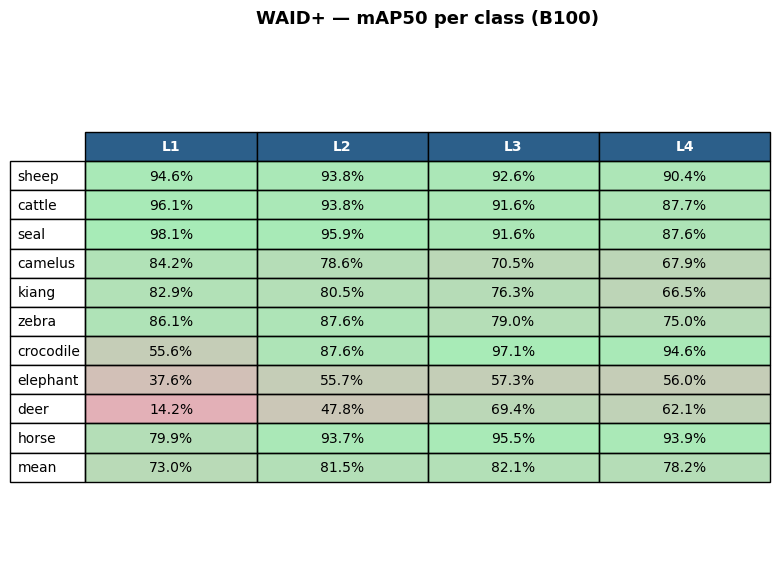

Guardado → /home/fozamorano/WAID/src/../plots/ConfMat_WAID+/tabla_mAP50-95_B100.pdf


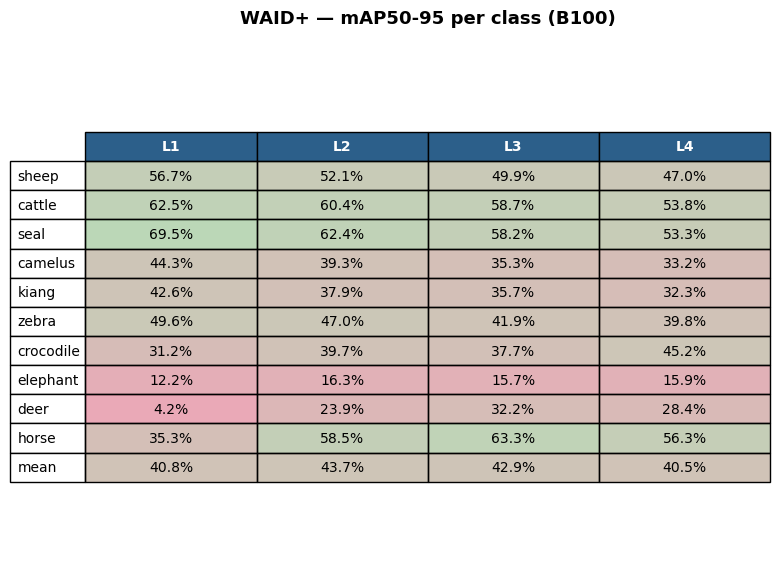

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

FILE_DIR = os.path.abspath("")
ROOT_DIR = os.path.join(FILE_DIR, "..")
LOG_DIR  = os.path.join(ROOT_DIR, "logs", "ValWAID+")
OUT_DIR  = os.path.join(ROOT_DIR, "plots", "ConfMat_WAID+")
os.makedirs(OUT_DIR, exist_ok=True)

LEVELS = ["L1", "L2", "L3", "L4"]
BATCH  = "B100"
METRICS = ["mAP50", "mAP50-95"]


def CargarClasesCSV(lvl, batch):
    """
    Lee class_{lvl}_{batch}.csv y devuelve un DataFrame limpio.
    Elimina filas vacías y la fila 'all'.
    """
    path = os.path.join(LOG_DIR, f"class_{lvl}_{batch}.csv")
    if not os.path.exists(path):
        print(f"[WARNING] Not found: {path}")
        return None

    df = pd.read_csv(path, index_col=0)
    df.columns = df.columns.str.strip()

    # Quitar filas vacías y fila resumen 'all'
    df = df[
        df["class_name"].notna() &
        (df["class_name"].astype(str).str.strip() != "") &
        (df["class_name"].astype(str).str.strip().str.lower() != "all")
    ]

    df = df.set_index("class_name")
    df[METRICS] = df[METRICS].apply(pd.to_numeric, errors="coerce")
    return df


def DibujarTablaMetrica(metrica="mAP50", batch="B100"):
    """
    Dibuja una tabla con:
    - filas = clases
    - columnas = L1, L2, L3, L4
    para la métrica indicada.
    """
    cols = {}

    for lvl in LEVELS:
        df = CargarClasesCSV(lvl, batch)
        if df is not None and metrica in df.columns:
            cols[lvl] = df[metrica]

    tabla = pd.DataFrame(cols)
    tabla.index.name = "Class"

    # Añadir media por columna
    tabla.loc["mean"] = tabla.mean()

    # Formato de texto en %
    cell_text = tabla.map(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "—").values.tolist()
    row_labels = list(tabla.index)
    col_labels = list(tabla.columns)

    # Colores suaves según valor
    colors = []
    for row in tabla.itertuples(index=False):
        row_colors = []
        for val in row:
            if pd.isna(val):
                row_colors.append("#f0f0f0")
            else:
                g = float(val)
                r = 1.0 - float(val)
                row_colors.append((r * 0.8, g * 0.8, 0.2, 0.35))
        colors.append(row_colors)

    fig_height = max(4, len(row_labels) * 0.45 + 1)
    fig, ax = plt.subplots(figsize=(8, fig_height))
    ax.axis("off")

    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellColours=colors,
        cellLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.5)

    # Estilo de cabecera
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#2c5f8a")
            cell.set_text_props(color="white", fontweight="bold")

    ax.set_title(
        f"WAID+ — {metrica} per class ({batch})",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    plt.tight_layout()
    out_pdf = os.path.join(OUT_DIR, f"tabla_{metrica}_{batch}.pdf")
    fig.savefig(out_pdf, dpi=150, bbox_inches="tight")
    print(f"Guardado → {out_pdf}")
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    DibujarTablaMetrica("mAP50", batch="B100")
    DibujarTablaMetrica("mAP50-95", batch="B100")